In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns                                     
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

In [5]:
# 1. Load Data
df = pd.read_csv(r"C:\Users\DELL\Downloads\loan_data.csv")

# 2. Feature Selection (Based on previous analysis)
num_features = ['person_income', 'loan_amnt', 'loan_int_rate', 'loan_percent_income']
cat_features = ['person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']
X = df[num_features + cat_features]
y = df['loan_status']

# 3. Encoding and Scaling
X = pd.get_dummies(X, columns=cat_features, drop_first=True).astype(float)
scaler = StandardScaler()
X[num_features] = scaler.fit_transform(X[num_features])

# 4. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [93]:
import pandas as pd

num_cols = df.select_dtypes(include=['int64','float64']).columns
num_cols = num_cols.drop('loan_status')

results_num = []

for col in num_cols:
    
    corr = df[col].corr(df['loan_status'])
    
    if abs(corr) > 0.05:
        decision = "Accept"
    else:
        decision = "Reject"
    
    results_num.append([col, corr, decision])

corr_results = pd.DataFrame(
    results_num,
    columns=['Feature','Correlation_with_Target','Decision']
)

corr_results.sort_values(by='Correlation_with_Target', ascending=False)

,Feature,Correlation_with_Target,Decision
5,loan_percent_income,0.384880,Accept
4,loan_int_rate,0.332005,Accept
3,loan_amnt,0.107714,Accept
7,credit_score,-0.007647,Reject
6,cb_person_cred_hist_length,-0.014851,Reject
2,person_emp_exp,-0.020481,Reject
0,person_age,-0.021476,Reject
1,person_income,-0.135808,Accept


In [7]:
# 5. Power Transform (to make features Gaussian-like)
pt = PowerTransformer(method='yeo-johnson')
X_train_pt = pt.fit_transform(X_train)
X_test_pt = pt.transform(X_test)

# 6. Address Class Imbalance with SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_pt, y_train)

Final Model Accuracy: 0.8272

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.80      0.88      6990
           1       0.57      0.92      0.70      2010

    accuracy                           0.83      9000
   macro avg       0.77      0.86      0.79      9000
weighted avg       0.88      0.83      0.84      9000



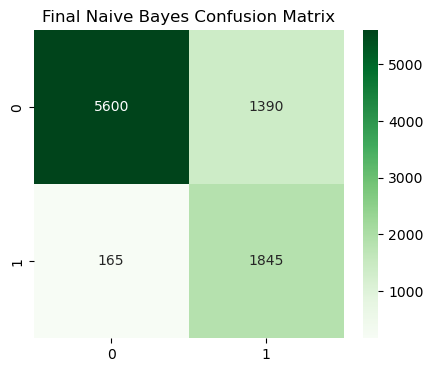

In [9]:
# 7. Final Model with Optimized Hyperparameters
# Using the var_smoothing discovered during GridSearch
final_nb = GaussianNB(var_smoothing=0.8111308307896871)
final_nb.fit(X_train_res, y_train_res)

# 8. Evaluation
y_pred = final_nb.predict(X_test_pt)
print(f'Final Model Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

# Plot Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens')
plt.title('Final Naive Bayes Confusion Matrix')
plt.show()

In [13]:
import pickle

# Ensure we are using the correct variables from the transformation and model cells
# final_nb was defined in the tuning cell, qt was defined in the transformation cell

try:
    with open('loan_nb_model.pkl', 'wb') as f:
        pickle.dump(final_nb, f)

    with open('quantile_transformer.pkl', 'wb') as f:
        pickle.dump(qt, f)

    print("Success: 'loan_nb_model.pkl' and 'quantile_transformer.pkl' have been created.")
except NameError as e:
    print(f"Error: {e}. Please make sure to run the Transformation and Model Tuning cells first.")

Error: name 'qt' is not defined. Please make sure to run the Transformation and Model Tuning cells first.
